
# Electric Vehicle Population Data

## Data Source
###### The Electric Vehicle Population Data is sourced from the Washington State Department of Licensing (DOL). It provides insights into the registration of Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) within the state.

## Collection Date and Location
###### The data collection date is not explicitly mentioned in the provided information. However, it seems to be regularly updated as indicated by the inclusion of monthly counts and the mention of publications from March 2022 onwards. The data is collected from vehicle registrations within the state of Washington, United States.

## Description
###### The dataset offers a detailed breakdown of registered BEVs and PHEVs, including information such as county, electric range, electric utility, and even census tract for more recent publications (June 2022 onwards). It also outlines eligibility criteria for Clean Alternative Fuel Vehicle (CAFV) exemptions and provides context regarding changes in data reporting processes.

## Data description and its uniqueness
###### - The data provides specific information about the electric vehicle population in Washington state, offering insights into the adoption rate and distribution across counties.
###### - It includes details such as electric range and electric utility, which can be crucial for understanding infrastructure needs and usage patterns.
###### - The inclusion of eligibility criteria for CAFV exemptions adds additional context regarding government initiatives and incentives driving EV adoption.

## Richness of data for Analysis
###### - The dataset offers a wide range of parameters for analysis, including geographic distribution, vehicle types, and eligibility criteria.
###### - Monthly counts provide the opportunity to track trends over time and assess the pace of EV adoption.
###### - The addition of fields like electric utility and census tract enhances the richness of the data, allowing for more detailed analysis and potentially uncovering correlations with demographic or socioeconomic factors.

## Feature Explaination
###### - A Battery Electric Vehicle (BEV) is an all-electric vehicle using one or more batteries to store the electrical energy that powers the motor and is charged by plugging the vehicle into an electric power source. A Plug-in Hybrid Electric Vehicle (PHEV) is a vehicle that uses one or more batteries to power an electric motor; uses another fuel, such as gasoline or diesel, to power an internal combustion engine or other propulsion sources; and is charged by plugging the vehicle into an electric power source.
###### - Clean Alternative Fuel Vehicle (CAFV) Eligibility is based on the fuel requirement and electric-only range requirement as outlined in RCW 82.08.809 and RCW 82.12.809 to be eligible for Alternative Fuel Vehicles retail sales and Washington State use tax exemptions. Sales or leases of these vehicles must occur on or after 8/1/2019 and meet the purchase price requirements to be eligible for Alternative Fuel Vehicles retail sales and Washington State use tax exemptions.
###### - Monthly count of vehicles for a county may change from this report and prior reports. Processes were implemented to more accurately assign county at the time of registration.
###### - Electric Range is no longer maintained for Battery Electric Vehicles (BEV) because new BEVs have an electric range of 30 miles or more. Zero (0) will be entered where the electric range has not been researched.
###### - Field 'Electric Utility' was added starting with the publication in March 2022.
###### - Field '2020 Census Tract' was added starting with the publication in June 2022.

In [ ]:
sc = spark.sparkContext

In [ ]:
spark

SparkSession - hive 
 
 
 SparkContext 

 Spark UI 

 
 Version 
 v3.3.2 
 Master 
 local[8] 
 AppName 
 Databricks Shell

In [ ]:
spark.catalog.listTables()

Out[174]: [Table(name='evdata', catalog='spark_catalog', namespace=['default'], description=None, tableType='MANAGED', isTemporary=False),
 Table(name='electric_vehicle_view', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]

## Load the data into a spark data frame

In [ ]:
from pyspark.sql.functions import col

ev=spark.read.csv('/FileStore/tables/Electric_Vehicle_Population_Data_1.csv', header=True, inferSchema=True);

# display the first 10 rows of the dataframe
# NOTE: We have not used toPandas() as it would defeat the whole purpose of Big Data use cases of Spark.
ev.show(n=10, truncate=False, vertical=True)

-RECORD 0---------------------------------------------------------------------------------------------------------
 VIN (1-10)                                        | 5YJYGDEE1L                                                   
 County                                            | King                                                         
 City                                              | Seattle                                                      
 State                                             | WA                                                           
 Postal Code                                       | 98122                                                        
 Model Year                                        | 2020                                                         
 Make                                              | TESLA                                                        
 Model                                             | MODEL Y                    

In [ ]:
ev.printSchema()

root
 |-- VIN (1-10): string (nullable = true)
 |-- County: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Model Year: integer (nullable = true)
 |-- Make: string (nullable = true)
 |-- Model: string (nullable = true)
 |-- Electric Vehicle Type: string (nullable = true)
 |-- Clean Alternative Fuel Vehicle (CAFV) Eligibility: string (nullable = true)
 |-- Electric Range: integer (nullable = true)
 |-- Base MSRP: integer (nullable = true)
 |-- Legislative District: integer (nullable = true)
 |-- DOL Vehicle ID: integer (nullable = true)
 |-- Vehicle Location: string (nullable = true)
 |-- Electric Utility: string (nullable = true)
 |-- 2020 Census Tract: long (nullable = true)



## Schema Change

### Based on the provided data and schema, here are some necessary changes to the schema:

##### - Postal Code should be a string rather than an integer because postal codes can contain leading zeros and are not used for arithmetic operations.
##### - Electric Utility might contain multiple values separated by "|", indicating different electric utility providers. This field could be better represented as an array of strings. In some instances, we also found the use of multiple "|" between two values. So, creating a consolidated array would be altogether a better option.
##### - BASE MSRP - For this column we had to replace 0 with NULL otherwise, it would cause issues in RDD manipulation with this column being integer

In [ ]:
from pyspark.sql.types import StructType, StructField, StringType, DecimalType, ArrayType

from pyspark.sql.functions import when, split

# Apply modifications to specific fields and handle zero values conversion elegantly
for field_name, data_type in modifications.items():
    if field_name == "Base MSRP":
        # Convert zero values to null for "Base MSRP" column
        ev = ev.withColumn(field_name, when(ev[field_name] == 0, None).otherwise(ev[field_name]))
    elif field_name == "Postal Code":
        # Convert to StringType for "Postal Code" column
        ev = ev.withColumn(field_name, ev[field_name].cast(StringType()))
    elif field_name == "Electric Utility":
        # Convert to ArrayType(StringType) for "Electric Utility" column
        ev = ev.withColumn(field_name, split(ev[field_name], "\\|").cast(ArrayType(StringType())))

# Show the modified schema
ev.printSchema()


root
 |-- VIN (1-10): string (nullable = true)
 |-- County: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: string (nullable = true)
 |-- Model Year: integer (nullable = true)
 |-- Make: string (nullable = true)
 |-- Model: string (nullable = true)
 |-- Electric Vehicle Type: string (nullable = true)
 |-- Clean Alternative Fuel Vehicle (CAFV) Eligibility: string (nullable = true)
 |-- Electric Range: integer (nullable = true)
 |-- Base MSRP: integer (nullable = true)
 |-- Legislative District: integer (nullable = true)
 |-- DOL Vehicle ID: integer (nullable = true)
 |-- Vehicle Location: string (nullable = true)
 |-- Electric Utility: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- 2020 Census Tract: long (nullable = true)



## Analysis of Data.

In [ ]:
cols = ev.columns
def unique_values_count(ev_modified, cols):
    for col_name in cols:
        #unique_count = ev_modified.select(col_name).distinct().count()
        unique_count = ev.filter(col(col_name).isNotNull()).select(col_name).distinct().count()
        print("There are {} unique values in {} column out of {}".format(unique_count, col_name, len(cols)))

unique_values_count(ev, cols)

There are 10830 unique values in VIN (1-10) column out of 17
There are 196 unique values in County column out of 17
There are 723 unique values in City column out of 17
There are 46 unique values in State column out of 17
There are 862 unique values in Postal Code column out of 17
There are 22 unique values in Model Year column out of 17
There are 40 unique values in Make column out of 17
There are 139 unique values in Model column out of 17
There are 2 unique values in Electric Vehicle Type column out of 17
There are 3 unique values in Clean Alternative Fuel Vehicle (CAFV) Eligibility column out of 17
There are 102 unique values in Electric Range column out of 17
There are 30 unique values in Base MSRP column out of 17
There are 49 unique values in Legislative District column out of 17
There are 177866 unique values in DOL Vehicle ID column out of 17
There are 861 unique values in Vehicle Location column out of 17
There are 76 unique values in Electric Utility column out of 17
There a

In [ ]:
# Count the number of rows
num_rows = ev.count()

# Get the number of columns
num_cols = len(ev.columns)

# Print the shape of the DataFrame
print("Shape of the DataFrame: ({}, {})".format(num_rows, num_cols))

Shape of the DataFrame: (177866, 17)


In [ ]:
# Generate summary statistics for numerical columns
summary_df = ev.summary()

# Show the summary statistics in tabular format
summary_df.toPandas()

,summary,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,2020 Census Tract
0,count,177866,177861,177861,177866,177861,177866,177866,177866,177866,177866,177866,3344,177477,177866,177857,177861
1,mean,None,None,None,None,98172.45350582758,2020.51551167733,None,500.5324840764331,None,None,58.842162077069254,57078.250598086124,29.12748130743702,2.2023126605454668E8,None,5.297672105555797E10
2,stddev,None,None,None,None,2442.4506680215495,2.989383950191924,None,14.919059754188417,None,None,91.98129769418426,22795.518131725097,14.892168539453753,7.584986612256481E7,None,1.578046771166894E9
3,min,1C4JJXN60P,Ada,Aberdeen,AE,10308,1997,ALFA ROMEO,330E,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,0,31950,1,4385,POINT (-104.50359 37.16543),1001020100
4,25%,None,None,None,None,98052.0,2019,None,500.0,None,None,0,39995,18,181466680,None,53033009702
5,50%,None,None,None,None,98122.0,2022,None,500.0,None,None,0,59900,33,228246952,None,53033029602
6,75%,None,None,None,None,98370.0,2023,None,500.0,None,None,75,69900,42,254840848,None,53053073001
7,max,ZASPATDWXR,Yuba,Zillah,WY,99577,2024,WHEEGO ELECTRIC CARS,XM,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,337,845000,49,479254772,POINT (-98.66992 29.5366501),56033000100


In [ ]:
# Drop rows with any null value
ev = ev.dropna()

In [ ]:
#Checking the size after dropping null values
#Count the number of rows
num_rows = ev.count()
# Get the number of columns
num_columns = len(ev.columns)
print("Number of Rows:", num_rows)
print("Number of Columns:", num_columns)

Number of Rows: 3331
Number of Columns: 17


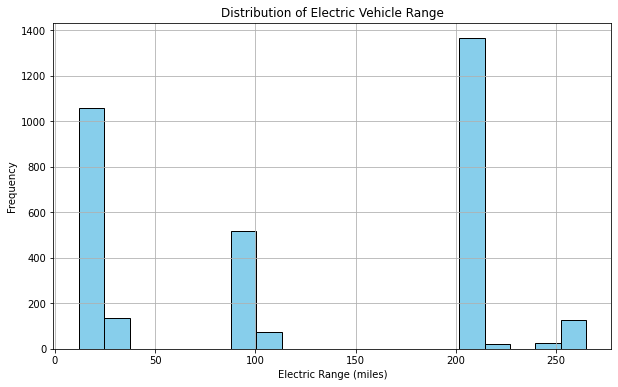

In [ ]:
import matplotlib.pyplot as plt

# Collect electric range data as a list
electric_range_data = ev.select("Electric Range").rdd.flatMap(lambda x: x).collect()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(electric_range_data, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Electric Vehicle Range')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Data Transformation

In [ ]:
from pyspark.sql.functions import col, when
from datetime import datetime

# Categorize Electric Range
ev = ev.withColumn("RangeCategory", when(col("Electric Range") < 150, "Short")
                                     .when((col("Electric Range") >= 150) & (col("Electric Range") < 300), "Medium")
                                     .otherwise("Long"))

# Categorize Model Year
ev = ev.withColumn("ModelYearCategory", when(col("Model Year") < 2015, "Old")
                                        .when((col("Model Year") >= 2015) & (col("Model Year") <= 2020), "Mid")
                                        .otherwise("New"))

# Calculate Age of Vehicle
current_year = datetime.now().year
ev = ev.withColumn("AgeOfVehicle", current_year - col("Model Year"))

## Explaination of each transformation:

##### Categorize Electric Range: This transformation categorizes the electric range of each vehicle into three categories: Short, Medium, or Long. It's required to segment vehicles based on their electric range for analysis or comparison purposes, such as understanding the distribution of vehicles with different ranges or assessing the market for vehicles with specific range capabilities.

##### Categorize Model Year: This transformation categorizes the model year of each vehicle into three categories: Old, Mid, or New. It's required to classify vehicles based on their model year for analysis, such as examining trends in EV adoption over time or assessing the age distribution of registered EVs.

##### Calculate Age of Vehicle: This transformation calculates the age of each vehicle by subtracting its model year from the current year. It's required to determine the age distribution of registered vehicles and understand factors such as the average age of EVs in the state or the rate of turnover in the EV market.

In [ ]:
ev.show(n=10, truncate=False, vertical=True)

-RECORD 0----------------------------------------------------------------------------------------------
 VIN (1-10)                                        | KNDJX3AE9H                                        
 County                                            | Thurston                                          
 City                                              | Olympia                                           
 State                                             | WA                                                
 Postal Code                                       | 98502                                             
 Model Year                                        | 2017                                              
 Make                                              | KIA                                               
 Model                                             | SOUL EV                                           
 Electric Vehicle Type                             | Battery Ele

## More Transformations
##### Changing the column names because we cannot save with special characters and spaces between feature column names.

In [ ]:
# Define the new column names with lowercased and underscored names
new_column_names = [col(col_name).alias(col_name.lower().replace(' ', '_').replace('(', '').replace(')', '')) for col_name in ev.columns]

# Select the DataFrame with the new column names
ev_changed = ev.select(*new_column_names)

In [ ]:
# Checking for the updated column names
ev_changed.show(n=10, truncate=False, vertical=True)

-RECORD 0--------------------------------------------------------------------------------------------
 vin_1-10                                        | KNDJX3AE9H                                        
 county                                          | Thurston                                          
 city                                            | Olympia                                           
 state                                           | WA                                                
 postal_code                                     | 98502                                             
 model_year                                      | 2017                                              
 make                                            | KIA                                               
 model                                           | SOUL EV                                           
 electric_vehicle_type                           | Battery Electric Vehicle (BEV) 

## Storing the data in a persistent table.

In [ ]:
# Define the name for the persistent table
persistent_table_name = "evdata"

# Save the DataFrame as a persistent table in the Spark warehouse location
ev_changed.write.mode("overwrite").saveAsTable(persistent_table_name)

In [ ]:
ev_changed.is_cached

Out[134]: False

In [ ]:
ev_changed.persist()

Out[135]: DataFrame[vin_1-10: string, county: string, city: string, state: string, postal_code: string, model_year: int, make: string, model: string, electric_vehicle_type: string, clean_alternative_fuel_vehicle_cafv_eligibility: string, electric_range: int, base_msrp: int, legislative_district: int, dol_vehicle_id: int, vehicle_location: string, electric_utility: array<string>, 2020_census_tract: bigint, rangecategory: string, modelyearcategory: string, ageofvehicle: int]

In [ ]:
ev_changed.is_cached

Out[136]: True

## Create a temporary view of the data

In [ ]:
# Create a temporary view of the DataFrame
ev_changed.createOrReplaceTempView("electric_vehicle_view")

## Data Exploration using Spark SQL


##### Analyzing how the average electric range of vehicles has changed over the years for both BEVs and PHEVs.

### Query 1: Average Electric Range by Model Year and Vehicle Type

**Description**: This query calculates the average electric range of electric vehicles, grouped by model year and type (BEV or PHEV), for those vehicles that have a non-zero electric range. This helps in understanding how the battery technology and efficiency in electric vehicles have evolved over the years.

In [ ]:
%sql
SELECT model_year, electric_vehicle_type, AVG(electric_range) AS average_range FROM electric_vehicle_view
WHERE electric_range > 0 GROUP BY model_year, electric_vehicle_type ORDER BY model_year, electric_vehicle_type;

model_year,electric_vehicle_type,average_range
2008,Battery Electric Vehicle (BEV),220.0
2010,Battery Electric Vehicle (BEV),245.0
2010,Plug-in Hybrid Electric Vehicle (PHEV),100.0
2011,Battery Electric Vehicle (BEV),245.0
2012,Battery Electric Vehicle (BEV),265.0
2012,Plug-in Hybrid Electric Vehicle (PHEV),33.0
2013,Battery Electric Vehicle (BEV),208.0
2014,Battery Electric Vehicle (BEV),208.0
2015,Plug-in Hybrid Electric Vehicle (PHEV),12.0
2016,Battery Electric Vehicle (BEV),93.0


### Same Query using Spark

In [ ]:
spark.sql("SELECT model_year, electric_vehicle_type, AVG(electric_range) AS average_range \
           FROM electric_vehicle_view \
           WHERE electric_range > 0 \
           GROUP BY model_year, electric_vehicle_type \
           ORDER BY model_year, electric_vehicle_type").show()

+----------+---------------------+------------------+
|model_year|electric_vehicle_type|     average_range|
+----------+---------------------+------------------+
|      2008| Battery Electric ...|             220.0|
|      2010| Battery Electric ...|             245.0|
|      2010| Plug-in Hybrid El...|             100.0|
|      2011| Battery Electric ...|             245.0|
|      2012| Battery Electric ...|             265.0|
|      2012| Plug-in Hybrid El...|              33.0|
|      2013| Battery Electric ...|             208.0|
|      2014| Battery Electric ...|             208.0|
|      2015| Plug-in Hybrid El...|              12.0|
|      2016| Battery Electric ...|              93.0|
|      2016| Plug-in Hybrid El...|              14.0|
|      2017| Battery Electric ...|              93.0|
|      2017| Plug-in Hybrid El...|14.336633663366337|
|      2018| Battery Electric ...|             111.0|
|      2018| Plug-in Hybrid El...|15.739279588336192|
|      2019| Plug-in Hybrid 

### Query 2: Premium Segment Electric Vehicles

**Description**: This query identifies the top electric vehicle models in the premium market segment, where the base manufacturer's suggested retail price (MSRP) exceeds $50,000. It provides the average MSRP and the count of vehicles registered for each model, ordered by the number of vehicles and then by the MSRP, to identify the most popular and highest valued models.


In [ ]:
spark.sql("""
    SELECT make, model, AVG(base_msrp) AS average_msrp, COUNT(*) AS count
    FROM electric_vehicle_view
    WHERE base_msrp > 50000
    GROUP BY make, model
    ORDER BY count DESC, average_msrp DESC
    LIMIT 10
""").show()

+--------+--------+------------------+-----+
|    make|   model|      average_msrp|count|
+--------+--------+------------------+-----+
|   TESLA| MODEL S| 69049.36369725385| 1493|
|     BMW|    530E| 54342.10526315789|  285|
|   VOLVO|    XC60|           52900.0|  222|
|   VOLVO|    XC90|           64950.0|   81|
|   TESLA|ROADSTER|105696.73913043478|   46|
|     BMW|    740E| 90375.80645161291|   31|
| PORSCHE| CAYENNE|           81100.0|   23|
|CADILLAC|     CT6|           75095.0|   13|
|  FISKER|   KARMA|          102000.0|   12|
| PORSCHE|PANAMERA|          184400.0|   10|
+--------+--------+------------------+-----+



### Query Repeated

### Query 3: Distribution of BEVs and PHEVs by County

**Description**: This query computes the total count of battery electric vehicles (BEVs) and plug-in hybrid electric vehicles (PHEVs) registered in each county. This can offer insights into the adoption patterns and preferences for electric vehicle types across different regions.


In [ ]:
spark.sql("""
    SELECT county,
           SUM(CASE WHEN `electric_vehicle_type` LIKE '%(BEV)%' THEN 1 ELSE 0 END) AS ev_count,
           SUM(CASE WHEN `electric_vehicle_type` LIKE '%(PHEV)%' THEN 1 ELSE 0 END) AS phev_count
    FROM electric_vehicle_view
    GROUP BY county
""").show(50)


+------------+--------+----------+
|      county|ev_count|phev_count|
+------------+--------+----------+
|    Thurston|      65|        34|
|   Snohomish|     248|       111|
|      Kitsap|      82|        56|
|        King|    1108|       613|
|      Yakima|      10|         6|
|     Cowlitz|      12|         4|
|       Clark|      98|        74|
|      Island|      26|        17|
|     Stevens|       1|         1|
|   Jefferson|      11|         4|
|   Klickitat|       4|         1|
|    Franklin|       7|         6|
|     Whatcom|      74|        27|
|      Pierce|     178|       119|
|      Skagit|      27|        14|
|     Clallam|      10|         5|
|    Kittitas|      10|         3|
|Grays Harbor|       9|         6|
|       Mason|      10|        10|
|      Benton|      23|        14|
|       Lewis|       7|         4|
|       Grant|       6|         2|
|      Chelan|      11|        11|
|    San Juan|      21|         8|
|     Spokane|      45|        35|
|     Douglas|      

### Query 4: Average Electric Range Excluding Short-Range Vehicles

**Description**: This query assesses the average electric range for electric vehicles, segmented by the age of the vehicle, but excluding those vehicles categorized as having "short" range. This analysis can help identify trends in battery longevity and efficiency improvements in older electric vehicles compared to newer ones. Here our data transformation is helping us to give good results.


In [ ]:
spark.sql("""
    SELECT
        ageofvehicle,
        AVG(electric_range) AS average_electric_range
    FROM
        electric_vehicle_view
    WHERE
        rangecategory != 'Short'
    GROUP BY
        ageofvehicle
    ORDER BY
        ageofvehicle
""").show()


+------------+----------------------+
|ageofvehicle|average_electric_range|
+------------+----------------------+
|          10|                 208.0|
|          11|                 208.0|
|          12|                 265.0|
|          13|                 245.0|
|          14|                 245.0|
|          16|                 220.0|
+------------+----------------------+

